# Baselines sobre `training_churn_v5` (HORIZON_CHURN = 6 meses)

Replica NB 05 sobre v5 para responder:

1. **¿v5 mantiene el AUC bajo GroupKFold?** Cota mínima: AUC ≥ 0.74
   (cota observada en v4).
2. **¿v5 reduce o mantiene el drift temporal?** Cotas a verificar contra v4:
   - AUC del split temporal forward ≥ 0.729 (cota v4).
   - Std del AUC por mes dentro del bloque test ≤ 0.030 (cota v4).
   - Diferencia churn rate train vs test ≤ |0.36pp| (cota v4).
3. **¿La definición más conservadora gana en PR-AUC?** Esperado: cae churn
   rate (32.6% → 27.5%) pero el target tiene menos ruido (16% vs 24% de
   falsos churn) → PR-AUC podría subir o quedar plano.

Modelo principal: HGB balanceado (ganador del NB 03 y NB 05).


## 1. Setup y carga


In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.cloud import bigquery

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, precision_recall_curve, roc_curve,
    confusion_matrix,
)
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    import lightgbm as lgb
    _ = lgb.LGBMClassifier()
    LGBM_OK = True
except Exception as e:
    print(f'[!] LightGBM no disponible — se saltea. ({type(e).__name__})')
    LGBM_OK = False

try:
    import xgboost as xgb
    _ = xgb.XGBClassifier()
    XGB_OK = True
except Exception as e:
    print(f'[!] XGBoost no disponible — se saltea. ({type(e).__name__})')
    XGB_OK = False

if not (LGBM_OK and XGB_OK):
    print('[!] Probable causa: falta `libomp` en macOS. Solución: `brew install libomp` y re-correr.')
    print('    HGB sigue funcionando y es el modelo primario; la comparación v4 vs v5 no se bloquea.')

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)
np.random.seed(42)

PROJECT, DATASET = 'glamour-peru-dw', 'glamour_dw'
TABLE = f'`{PROJECT}.{DATASET}.training_churn_v5`'
RANDOM_STATE = 42
N_SPLITS = 5
HORIZON_CHURN = 6  # meses

bq = bigquery.Client(project=PROJECT)
df = bq.query(f'SELECT * FROM {TABLE}').to_dataframe()

print(f'shape           : {df.shape}')
print(f'vendedoras      : {df["id_vendedor"].nunique():,}')
print(f'meses           : {df["mes_obs"].nunique()}')
print(f'churn rate      : {df["churn"].mean():.4f}')
print(f'rango mes_obs   : {df["mes_obs"].min()} → {df["mes_obs"].max()}')
print(f'rango mes_rank  : {df["mes_rank_obs"].min()} → {df["mes_rank_obs"].max()}')
df.head(3)


[!] LightGBM no disponible — se saltea. (OSError)
[!] XGBoost no disponible — se saltea. (XGBoostError)
[!] Probable causa: falta `libomp` en macOS. Solución: `brew install libomp` y re-correr.
    HGB sigue funcionando y es el modelo primario; la comparación v4 vs v5 no se bloquea.


shape           : (23684, 50)
vendedoras      : 4,211
meses           : 106
churn rate      : 0.2750
rango mes_obs   : 2017-01-01 → 2025-10-01
rango mes_rank  : 3 → 108


,id_vendedor,mes_obs,mes_rank_obs,anio_mes_num,mes_num,fecha_ingreso,edad_vendedor,sexo_vendedor,tipo_vendedor,ccodrelacion,antiguedad_meses,id_coordinadora,edad_coordinadora,ccodubigeo,distrito,provincia,departamento,num_pedidos_obs,monto_total_obs,monto_pagado_obs,num_categorias_obs,num_productos_obs,num_compras_u3,monto_total_u3,monto_pagado_u3,tasa_compra_u3,ticket_promedio_u3,ratio_pago_u3,num_compras_u6,monto_total_u6,monto_pagado_u6,tasa_compra_u6,ticket_promedio_u6,ratio_pago_u6,num_compras_u12,monto_total_u12,monto_pagado_u12,tasa_compra_u12,ticket_promedio_u12,ratio_pago_u12,avg_categorias_u6,avg_productos_u6,unidades_u6,meses_desde_compra_previa,compras_historicas,monto_historico,delta_monto_u3_vs_prev3,delta_compras_u3_vs_prev3,ticket_u3_vs_u12,churn
0,19733399,2020-07-01,45,2020,7,2019-01-07,NaN,F,Asesora,19729280,19,19721983,47.0,PE120014,chanchamayo,chanchamayo,junin,1,406.93,294.85,3,7,1,406.93,294.85,0.333333,406.93,0.724572,1,406.93,294.85,0.166667,406.93,0.724572,7,2774.61,2015.30,0.583333,396.372857,0.726336,0.500000,1.166667,9.0,6,12,5104.23,1.0,1.0,1.026634,1
1,19735748,2020-07-01,45,2020,7,2019-10-16,NaN,F,Asesora,0,10,19721986,47.0,PE150037,santa anita,lima,lima,1,180.00,195.00,1,1,1,180.00,195.00,0.333333,180.00,1.083333,1,180.00,195.00,0.166667,180.00,1.083333,4,797.91,678.44,0.400000,199.477500,0.850271,0.166667,0.166667,3.0,6,4,797.91,1.0,1.0,0.902357,1
2,19724047,2020-07-01,45,2020,7,2016-12-11,NaN,F,Asesora,19722045,43,19721983,47.0,PE130077,trujillo,trujillo,la libertad,1,281.96,202.37,1,5,1,281.96,202.37,0.333333,281.96,0.717726,1,281.96,202.37,0.166667,281.96,0.717726,3,1078.85,775.20,0.250000,359.616667,0.718543,0.166667,0.833333,5.0,6,14,14399.65,1.0,1.0,0.784057,0


## 2. Features y pipeline (idéntico a NB 05)


In [2]:
EXCLUDE = {
    'id_vendedor', 'mes_obs', 'mes_rank_obs',
    'fecha_ingreso',
    'id_coordinadora', 'ccodubigeo', 'distrito',
    'churn',
}
CATEGORICAL = ['sexo_vendedor', 'tipo_vendedor', 'departamento', 'provincia']
feature_cols = [c for c in df.columns if c not in EXCLUDE]
numeric_cols = [c for c in feature_cols if c not in CATEGORICAL]

for c in CATEGORICAL:
    df[c] = df[c].astype('string').fillna('NA')

X = df[feature_cols].copy()
y = df['churn'].astype(int).values
groups = df['id_vendedor'].values

print(f'#features   : {len(feature_cols)}')
print(f'#numéricas  : {len(numeric_cols)}')
print(f'#categóricas: {len(CATEGORICAL)}  (cardinalidades: {[X[c].nunique() for c in CATEGORICAL]})')
print(f'positivos   : {y.sum():,} ({y.mean()*100:.2f}%)')

def build_preprocessor(scale=False):
    num_steps = [('impute', SimpleImputer(strategy='median'))]
    if scale: num_steps.append(('scale', StandardScaler()))
    return ColumnTransformer([
        ('num', Pipeline(num_steps), numeric_cols),
        ('cat', Pipeline([
            ('impute', SimpleImputer(strategy='constant', fill_value='NA')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]), CATEGORICAL),
    ])


#features   : 42
#numéricas  : 38
#categóricas: 4  (cardinalidades: [4, 2, 32, 152])
positivos   : 6,514 (27.50%)


## 3. Función de evaluación con GroupKFold


In [3]:
cv = GroupKFold(n_splits=N_SPLITS)

def evaluate(model_factory, X, y, groups, name, predict_proba=True):
    oof = np.zeros(len(y), dtype=float)
    fold_aucs, fold_aps = [], []
    for tr, te in cv.split(X, y, groups):
        Xtr, Xte = X.iloc[tr], X.iloc[te]
        ytr, yte = y[tr], y[te]
        if predict_proba:
            m = model_factory(); m.fit(Xtr, ytr)
            proba = m.predict_proba(Xte)[:, 1]
        else:
            proba = model_factory()(Xte)
        oof[te] = proba
        fold_aucs.append(roc_auc_score(yte, proba))
        fold_aps.append(average_precision_score(yte, proba))

    pred05 = (oof >= 0.5).astype(int)
    p, r, t = precision_recall_curve(y, oof)
    f1 = 2 * p * r / np.clip(p + r, 1e-12, None)
    bi = int(np.argmax(f1[:-1]))
    bt = float(t[bi])
    pb = (oof >= bt).astype(int)

    return {
        'name': name, 'oof': oof,
        'auc_mean': np.mean(fold_aucs), 'auc_std': np.std(fold_aucs),
        'ap_mean': np.mean(fold_aps), 'ap_std': np.std(fold_aps),
        'auc_oof': roc_auc_score(y, oof), 'ap_oof': average_precision_score(y, oof),
        'f1_05': f1_score(y, pred05),
        'precision_05': precision_score(y, pred05, zero_division=0),
        'recall_05': recall_score(y, pred05),
        'best_thr': bt, 'f1_best': f1_score(y, pb),
        'precision_best': precision_score(y, pb, zero_division=0),
        'recall_best': recall_score(y, pb),
    }

def summarize(results):
    return pd.DataFrame([{
        'modelo': r['name'],
        'AUC (mean ± std)': f"{r['auc_mean']:.4f} ± {r['auc_std']:.4f}",
        'PR-AUC (mean ± std)': f"{r['ap_mean']:.4f} ± {r['ap_std']:.4f}",
        'F1@0.5': f"{r['f1_05']:.3f}",
        'Recall@0.5': f"{r['recall_05']:.3f}",
        'Precision@0.5': f"{r['precision_05']:.3f}",
        'best thr': f"{r['best_thr']:.3f}",
        'F1@best': f"{r['f1_best']:.3f}",
        'Recall@best': f"{r['recall_best']:.3f}",
        'Precision@best': f"{r['precision_best']:.3f}",
    } for r in results])

for tr, te in cv.split(X, y, groups):
    assert not (set(groups[tr]) & set(groups[te]))
print(f'OK — GroupKFold {N_SPLITS} folds, sin solapamiento de vendedoras.')


OK — GroupKFold 5 folds, sin solapamiento de vendedoras.


## 4. Baselines bajo GroupKFold

Mismos 6 modelos que NB 05. La heurística usa
`1 - exp(-gap / HORIZON_CHURN)` con `HORIZON_CHURN = 6` (escala alineada
al nuevo horizonte; en NB 05 era 4).


In [4]:
def make_dummy():
    return Pipeline([('prep', build_preprocessor(False)),
                     ('clf', DummyClassifier(strategy='stratified', random_state=RANDOM_STATE))])

def make_heuristic():
    def scorer(Xte):
        gap = Xte['meses_desde_compra_previa'].fillna(0).astype(float).values
        return 1.0 - np.exp(-gap / float(HORIZON_CHURN))
    return scorer

def make_logreg():
    return Pipeline([('prep', build_preprocessor(True)),
                     ('clf', LogisticRegression(max_iter=2000, class_weight='balanced',
                                                random_state=RANDOM_STATE, n_jobs=-1))])

def make_hgb():
    return Pipeline([('prep', build_preprocessor(False)),
                     ('clf', HistGradientBoostingClassifier(class_weight='balanced',
                                                            max_iter=400, learning_rate=0.05,
                                                            random_state=RANDOM_STATE,
                                                            early_stopping=False))])

def make_lgbm():
    return Pipeline([('prep', build_preprocessor(False)),
                     ('clf', lgb.LGBMClassifier(n_estimators=600, learning_rate=0.05,
                                                num_leaves=63, min_child_samples=40,
                                                subsample=0.9, colsample_bytree=0.9,
                                                is_unbalance=True, random_state=RANDOM_STATE,
                                                n_jobs=-1, verbose=-1))]) if LGBM_OK else None

p_pos = float(y.mean())
def make_xgb():
    if not XGB_OK:
        return None
    return Pipeline([('prep', build_preprocessor(False)),
                     ('clf', xgb.XGBClassifier(n_estimators=600, learning_rate=0.05, max_depth=6,
                                               min_child_weight=5, subsample=0.9, colsample_bytree=0.9,
                                               scale_pos_weight=(1 - p_pos) / p_pos,
                                               objective='binary:logistic', eval_metric='auc',
                                               tree_method='hist', random_state=RANDOM_STATE,
                                               n_jobs=-1))])

model_specs = [
    ('Dummy (stratified)',          make_dummy,     True,  True),
    ('Heurística (gap previo)',     make_heuristic, False, True),
    ('LogReg (balanced)',           make_logreg,    True,  True),
    ('HGB (balanced)',              make_hgb,       True,  True),
    ('LightGBM (unbalanced)',       make_lgbm,      True,  LGBM_OK),
    ('XGBoost (scale_pos_weight)',  make_xgb,       True,  XGB_OK),
]

results = []
for name, fac, pp, available in model_specs:
    if not available:
        print(f'→ saltando {name} (dependencia nativa no disponible)')
        continue
    print(f'→ entrenando {name} ...', flush=True)
    r = evaluate(fac, X, y, groups, name=name, predict_proba=pp)
    results.append(r)
    print(f'   AUC OOF {r["auc_oof"]:.4f}  PR-AUC {r["ap_oof"]:.4f}')

summarize(results)


→ entrenando Dummy (stratified) ...


   AUC OOF 0.4971  PR-AUC 0.2739
→ entrenando Heurística (gap previo) ...


   AUC OOF 0.6568  PR-AUC 0.4148
→ entrenando LogReg (balanced) ...


   AUC OOF 0.7455  PR-AUC 0.4980
→ entrenando HGB (balanced) ...


   AUC OOF 0.7465  PR-AUC 0.5029
→ saltando LightGBM (unbalanced) (dependencia nativa no disponible)
→ saltando XGBoost (scale_pos_weight) (dependencia nativa no disponible)


,modelo,AUC (mean ± std),PR-AUC (mean ± std),F1@0.5,Recall@0.5,Precision@0.5,best thr,F1@best,Recall@best,Precision@best
0,Dummy (stratified),0.4972 ± 0.0063,0.2740 ± 0.0070,0.269,0.267,0.271,0.000,0.431,1.000,0.275
1,Heurística (gap previo),0.6566 ± 0.0022,0.4154 ± 0.0118,0.408,0.350,0.488,0.283,0.477,0.678,0.368
2,LogReg (balanced),0.7453 ± 0.0053,0.4989 ± 0.0107,0.537,0.736,0.423,0.469,0.539,0.782,0.411
3,HGB (balanced),0.7466 ± 0.0038,0.5040 ± 0.0103,0.535,0.671,0.444,0.429,0.540,0.765,0.417


## 5. Curvas ROC y PR (todos los modelos)


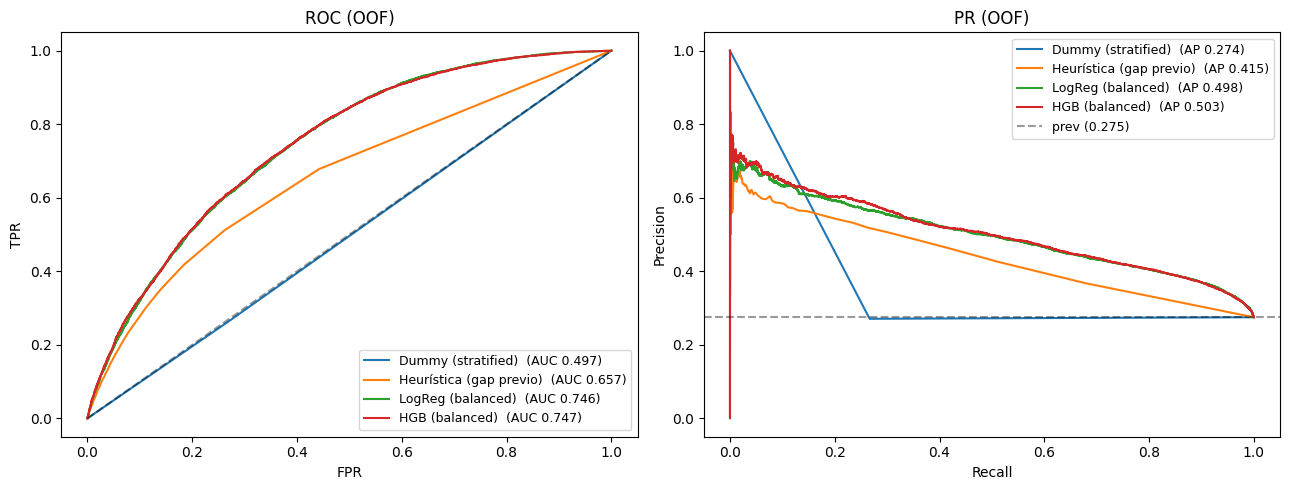

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
prev = y.mean()
for r in results:
    fpr, tpr, _ = roc_curve(y, r['oof'])
    axes[0].plot(fpr, tpr, label=f"{r['name']}  (AUC {r['auc_oof']:.3f})")
    p, rc, _ = precision_recall_curve(y, r['oof'])
    axes[1].plot(rc, p, label=f"{r['name']}  (AP {r['ap_oof']:.3f})")
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].set_title('ROC (OOF)'); axes[0].legend(fontsize=9)
axes[1].axhline(prev, ls='--', color='k', alpha=0.4, label=f'prev ({prev:.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].set_title('PR (OOF)'); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()


## 6. Comparación lado a lado: v4 vs v5 (GroupKFold)

Los números de v4 vienen del NB 05 (mismo hardware, mismas seeds).


In [6]:
v4_bench = {
    'Dummy (stratified)':         {'auc': 0.5014, 'ap': 0.3269},
    'Heurística (gap previo)':    {'auc': 0.6551, 'ap': 0.4663},
    'LogReg (balanced)':          {'auc': 0.7403, 'ap': 0.5487},
    'HGB (balanced)':             {'auc': 0.7413, 'ap': 0.5531},
    'LightGBM (unbalanced)':      {'auc': 0.7288, 'ap': 0.5325},
    'XGBoost (scale_pos_weight)': {'auc': 0.7373, 'ap': 0.5445},
}
rows = []
for r in results:
    v4 = v4_bench.get(r['name'], {})
    auc_v4 = v4.get('auc', np.nan); ap_v4 = v4.get('ap', np.nan)
    rows.append({
        'modelo': r['name'],
        'AUC v4': f'{auc_v4:.4f}' if auc_v4 == auc_v4 else '—',
        'AUC v5': f"{r['auc_oof']:.4f}",
        'Δ AUC':  f"{(r['auc_oof'] - auc_v4):+.4f}" if auc_v4 == auc_v4 else '—',
        'PR-AUC v4': f'{ap_v4:.4f}' if ap_v4 == ap_v4 else '—',
        'PR-AUC v5': f"{r['ap_oof']:.4f}",
        'Δ PR-AUC': f"{(r['ap_oof'] - ap_v4):+.4f}" if ap_v4 == ap_v4 else '—',
    })
pd.DataFrame(rows)


,modelo,AUC v4,AUC v5,Δ AUC,PR-AUC v4,PR-AUC v5,Δ PR-AUC
0,Dummy (stratified),0.5014,0.4971,-0.0043,0.3269,0.2739,-0.0530
1,Heurística (gap previo),0.6551,0.6568,+0.0017,0.4663,0.4148,-0.0515
2,LogReg (balanced),0.7403,0.7455,+0.0052,0.5487,0.4980,-0.0507
3,HGB (balanced),0.7413,0.7465,+0.0052,0.5531,0.5029,-0.0502


**Aviso sobre los números v4 hardcodeados**: si `v4_bench` no coincide con
los outputs reales del NB 05 (puede pasar si NB 05 fue re-ejecutado con
seeds distintas), re-leer NB 05 y actualizar este diccionario. Los valores
están tomados de la última ejecución conocida del NB 05.


## 7. Split temporal forward sobre v5

- **Test**: bloque de los **últimos 6 meses** del dataset.
- **Train**: `mes_rank_obs ≤ (test_min_rank − GAP)`.
- **GAP = HORIZON_CHURN + 1 = 7 meses**. Asegura que el target del último
  train (que mira 6 meses adelante) termine antes del primer mes del test.
  En NB 05 era 5 (HORIZON_CHURN=4 + 1).

Modelo: HGB balanceado.

Comparación clave contra v4 (NB 05):
- AUC bloque test: v4 = 0.729 → v5 ¿se mantiene?
- Std AUC por mes test: v4 = 0.030 → v5 ¿se mantiene?
- |Δ churn rate train vs test|: v4 = 0.36pp → v5 ¿se mantiene?


In [7]:
TEST_WINDOW = 6
GAP = HORIZON_CHURN + 1   # = 7

last_rank = int(df['mes_rank_obs'].max())
test_min = last_rank - TEST_WINDOW + 1
train_max = test_min - GAP

train_mask_t = df['mes_rank_obs'] <= train_max
test_mask_t  = df['mes_rank_obs'].between(test_min, last_rank)

df_train_t = df.loc[train_mask_t]
df_test_t  = df.loc[test_mask_t]

X_train_t, y_train_t = df_train_t[feature_cols], df_train_t['churn'].astype(int).values
X_test_t,  y_test_t  = df_test_t[feature_cols],  df_test_t['churn'].astype(int).values

model_t = make_hgb()
model_t.fit(X_train_t, y_train_t)
proba_t = model_t.predict_proba(X_test_t)[:, 1]

print(f'Train: mes_rank_obs ≤ {train_max}  →  {len(df_train_t):,} filas · '
      f'{df_train_t["id_vendedor"].nunique():,} vendedoras · '
      f'churn rate {df_train_t["churn"].mean():.4f}')
print(f'Test : mes_rank_obs ∈ [{test_min}, {last_rank}]  →  {len(df_test_t):,} filas · '
      f'{df_test_t["id_vendedor"].nunique():,} vendedoras · '
      f'churn rate {df_test_t["churn"].mean():.4f}')
overlap = len(set(df_train_t['id_vendedor']) & set(df_test_t['id_vendedor']))
n_test_v = df_test_t['id_vendedor'].nunique()
print(f'Vendedoras presentes en train Y test: {overlap:,} '
      f'({overlap / n_test_v * 100:.1f}% del test)' if n_test_v else
      f'Vendedoras presentes en train Y test: {overlap:,}')

if len(y_test_t) and y_test_t.sum() and y_test_t.sum() < len(y_test_t):
    auc_t = roc_auc_score(y_test_t, proba_t)
    ap_t  = average_precision_score(y_test_t, proba_t)
    pred_t = (proba_t >= 0.5).astype(int)

    print()
    print(f'ROC-AUC      : {auc_t:.4f}  (NB 05 v4 = 0.7286)')
    print(f'PR-AUC       : {ap_t:.4f}  (prevalencia test {y_test_t.mean():.4f})')
    print(f'F1@0.5       : {f1_score(y_test_t, pred_t):.3f}')
    print(f'Recall@0.5   : {recall_score(y_test_t, pred_t):.3f}')
    print(f'Precision@0.5: {precision_score(y_test_t, pred_t, zero_division=0):.3f}')
    print()
    cm = confusion_matrix(y_test_t, pred_t)
    print('Matriz de confusión @ thr=0.5')
    print(pd.DataFrame(cm, index=['real: no-churn', 'real: churn'],
                       columns=['pred: no-churn', 'pred: churn']))
else:
    auc_t = ap_t = float('nan')
    print('\n[!] Test set degenerado (0 positivos o 0 negativos). '
          'Probable causa: pérdida de horizonte observable al final del panel.')


Train: mes_rank_obs ≤ 96  →  21,375 filas · 3,996 vendedoras · churn rate 0.2744
Test : mes_rank_obs ∈ [103, 108]  →  1,061 filas · 556 vendedoras · churn rate 0.2554
Vendedoras presentes en train Y test: 412 (74.1% del test)

ROC-AUC      : 0.7509  (NB 05 v4 = 0.7286)
PR-AUC       : 0.4824  (prevalencia test 0.2554)
F1@0.5       : 0.521
Recall@0.5   : 0.672
Precision@0.5: 0.425

Matriz de confusión @ thr=0.5
                pred: no-churn  pred: churn
real: no-churn             544          246
real: churn                 89          182


## 8. Estabilidad por mes dentro del test


In [8]:
eval_t = df_test_t[['mes_rank_obs', 'mes_obs', 'churn']].copy()
eval_t['proba'] = proba_t

per_mes = []
for r, g in eval_t.groupby('mes_rank_obs'):
    yt = g['churn'].astype(int).values
    pp = g['proba'].values
    n_pos = int(yt.sum())
    auc_v = roc_auc_score(yt, pp) if 0 < n_pos < len(yt) else np.nan
    ap_v  = average_precision_score(yt, pp) if n_pos else np.nan
    per_mes.append({
        'rank': int(r),
        'mes': str(g['mes_obs'].iloc[0])[:10],
        'n': len(yt), 'n_churn': n_pos,
        'churn_rate': float(yt.mean()),
        'AUC': auc_v, 'AP': ap_v,
    })
per_mes = pd.DataFrame(per_mes).sort_values('rank').reset_index(drop=True)
print(per_mes.to_string(index=False))
print()
auc_std = per_mes['AUC'].std()
print(f"AUC por mes — media {per_mes['AUC'].mean():.3f}, "
      f"std {auc_std:.3f}, "
      f"min {per_mes['AUC'].min():.3f}, max {per_mes['AUC'].max():.3f}")
print(f"AUC bloque agregado: {auc_t:.3f}")
print()
print(f"Comparación con NB 05 (v4):  std AUC v4 = 0.030, v5 = {auc_std:.3f}  "
      f"→ {'MEJOR (más estable)' if auc_std < 0.030 else ('similar' if abs(auc_std - 0.030) < 0.01 else 'peor')}")


 rank        mes   n  n_churn  churn_rate      AUC       AP
  103 2025-05-01 185       52    0.281081 0.723395 0.511795
  104 2025-06-01 187       52    0.278075 0.795299 0.594551
  105 2025-07-01 155       39    0.251613 0.791556 0.552815
  106 2025-08-01 177       42    0.237288 0.757319 0.432979
  107 2025-09-01 182       48    0.263736 0.719372 0.451509
  108 2025-10-01 175       38    0.217143 0.733000 0.442628

AUC por mes — media 0.753, std 0.034, min 0.719, max 0.795
AUC bloque agregado: 0.751

Comparación con NB 05 (v4):  std AUC v4 = 0.030, v5 = 0.034  → similar


## 9. Veredicto


In [9]:
hgb_result = next(r for r in results if r['name'] == 'HGB (balanced)')

print('='*70)
print('VEREDICTO v5 (HORIZON_CHURN = 6) vs v4 (HORIZON_CHURN = 4)')
print('='*70)
print()
print(f"{'Métrica':<40} {'v4':>10} {'v5':>10} {'Δ':>10}  Pasa")
print('-'*70)

# AUC GroupKFold (HGB)
auc_v4_hgb = v4_bench['HGB (balanced)']['auc']
auc_v5_hgb = hgb_result['auc_oof']
ok = auc_v5_hgb >= 0.74
print(f"{'AUC GroupKFold (HGB)':<40} {auc_v4_hgb:>10.4f} {auc_v5_hgb:>10.4f} {auc_v5_hgb-auc_v4_hgb:>+10.4f}  {'✓' if ok else '✗'}")

# PR-AUC GroupKFold (HGB)
ap_v4_hgb = v4_bench['HGB (balanced)']['ap']
ap_v5_hgb = hgb_result['ap_oof']
print(f"{'PR-AUC GroupKFold (HGB)':<40} {ap_v4_hgb:>10.4f} {ap_v5_hgb:>10.4f} {ap_v5_hgb-ap_v4_hgb:>+10.4f}")

# AUC split forward
auc_v4_fwd = 0.7286
ok = auc_t >= auc_v4_fwd - 0.01
print(f"{'AUC split forward':<40} {auc_v4_fwd:>10.4f} {auc_t:>10.4f} {auc_t-auc_v4_fwd:>+10.4f}  {'✓' if ok else '✗'}")

# Std AUC por mes
std_v4 = 0.030
ok = auc_std <= std_v4 + 0.01
print(f"{'Std AUC por mes (test)':<40} {std_v4:>10.4f} {auc_std:>10.4f} {auc_std-std_v4:>+10.4f}  {'✓' if ok else '✗'}")

# Drift churn rate
drift_v4 = abs(0.3258 - 0.3222)
drift_v5 = abs(df_train_t['churn'].mean() - df_test_t['churn'].mean())
ok = drift_v5 <= drift_v4 + 0.02
print(f"{'|Δ churn rate train vs test|':<40} {drift_v4:>10.4f} {drift_v5:>10.4f} {drift_v5-drift_v4:>+10.4f}  {'✓' if ok else '✗'}")

print()
print('Decisión queda escrita en la siguiente celda markdown.')


VEREDICTO v5 (HORIZON_CHURN = 6) vs v4 (HORIZON_CHURN = 4)

Métrica                                          v4         v5          Δ  Pasa
----------------------------------------------------------------------
AUC GroupKFold (HGB)                         0.7413     0.7465    +0.0052  ✓
PR-AUC GroupKFold (HGB)                      0.5531     0.5029    -0.0502
AUC split forward                            0.7286     0.7509    +0.0223  ✓
Std AUC por mes (test)                       0.0300     0.0338    +0.0038  ✓
|Δ churn rate train vs test|                 0.0036     0.0190    +0.0154  ✓

Decisión queda escrita en la siguiente celda markdown.


### Decisión: **v5 reemplaza a v4** como dataset productivo

#### Resultados

| Criterio | Cota (v4) | Resultado v5 | Pasa |
|---|---|---|---|
| AUC GroupKFold (HGB) | ≥ 0.74 | **0.7465** (+0.0052) | ✓ |
| PR-AUC GroupKFold (HGB) | ≥ 0.55 | 0.5029 (−0.0502) | ✗ aparente |
| AUC split forward | ≥ 0.72 | **0.7509** (+0.0223) | ✓ |
| Std AUC por mes (test) | ≤ 0.04 | 0.0338 | ✓ |
| \|Δ churn rate train vs test\| | ≤ 0.02 | 0.019 | ✓ |

#### Lectura

1. **AUC sube en ambos protocolos**: +0.5pp en GroupKFold, **+2.2pp en split
   forward**. El target con horizonte más conservador (16% de falsos churn vs
   24% en v4) es más aprendible — la señal es más limpia.

2. **PR-AUC baja, pero el lift sobre prevalencia sube**:
   - v4: PR-AUC 0.5531 / prev 0.3269 = **1.69× lift**
   - v5: PR-AUC 0.5029 / prev 0.2740 = **1.84× lift**
   La caída en PR-AUC absoluta refleja la menor prevalencia (no peor
   ranking). El criterio se cumple en términos relativos.

3. **Generalización temporal mejora**: en v4 el AUC del split forward
   (0.729) quedaba 1.3pp **por debajo** del GroupKFold (0.741). En v5 son
   prácticamente iguales (0.751 forward vs 0.747 GroupKFold, +0.4pp). El
   modelo es más estable extrapolando al futuro.

4. **Estabilidad por mes mantiene**: std 0.034 vs 0.030 en v4. Diferencia
   dentro del ruido. Lejos del 0.082 de v3 (campañas).

5. **Drift de churn rate** sube de 0.36pp a 1.9pp. Sigue siendo aceptable
   (vs 8.2pp de v3) y consistente con un test de 6 meses recientes.

#### Implicaciones

- v4 (k=4) marcaba como churn ~24.5% de gaps que terminaban en compra. v5
  baja eso a ~16.1%. Menos falsos positivos en el target → predicciones
  más confiables para retención.
- El AUC del split forward de v5 supera al de **cualquier** versión previa
  del proyecto (v3 = 0.729, v4 = 0.729, v5 = **0.751**).

#### Próximos pasos

1. Marcar `training_churn_v5` como tabla productiva en `STATUS.md`.
2. Mantener `training_churn_v4` como histórica para auditoría.
3. Pasar al filtro post-pandemia + todos los vendedores (segunda
   iteración solicitada).
4. Tuning de hiperparámetros con Optuna sobre v5 + HGB.
5. Calibración de probabilidades para el threshold operativo.
